# 11 - Model Comparison

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 8)

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES_DIR = PROJECT_DIR / "reports" / "tables"
FIGURES_DIR = PROJECT_DIR / "reports" / "figures" / "evaluation"

comparison = pd.read_csv(TABLES_DIR / "model_comparison.csv")
comparison

,model,use_case,genre_precision_at_k,artist_precision_at_k,avg_popularity,diversity_score,novelty_score,catalog_coverage,avg_response_time_s
0,Cosine Similarity,similar_song,1.000,0.134,31.4320,0.1000,0.6857,0.0219,0.0061
1,KNN,playlist,1.000,NaN,36.6533,0.1000,0.6335,0.0017,0.0151
2,Weighted Mood Similarity,mood,NaN,NaN,85.9000,0.7750,0.1410,0.0004,0.0083
3,TF-IDF,genre,1.000,NaN,60.7600,0.1000,0.3924,0.0017,0.0234
4,Hybrid (09),similar_song,0.714,0.204,31.4030,0.2965,0.6860,0.0220,0.0806


## Radar chart

In [2]:
radar_metrics = ["avg_popularity", "diversity_score", "novelty_score", "catalog_coverage", "speed_score"]

radar_df = comparison.copy()
radar_df["speed_score"] = 1 / radar_df["avg_response_time_s"]

normalized = radar_df[["model"]].copy()
for metric in radar_metrics:
    values = radar_df[metric]
    normalized[metric] = (values - values.min()) / (values.max() - values.min())

normalized

,model,avg_popularity,diversity_score,novelty_score,catalog_coverage,speed_score
0,Cosine Similarity,0.000532,0.000000,0.999450,0.995370,1.000000
1,KNN,0.096341,0.000000,0.903670,0.060185,0.355171
2,Weighted Mood Similarity,1.000000,1.000000,0.000000,0.000000,0.713237
3,TF-IDF,0.538690,0.000000,0.461284,0.060185,0.200149
4,Hybrid (09),0.000000,0.291111,1.000000,1.000000,0.000000


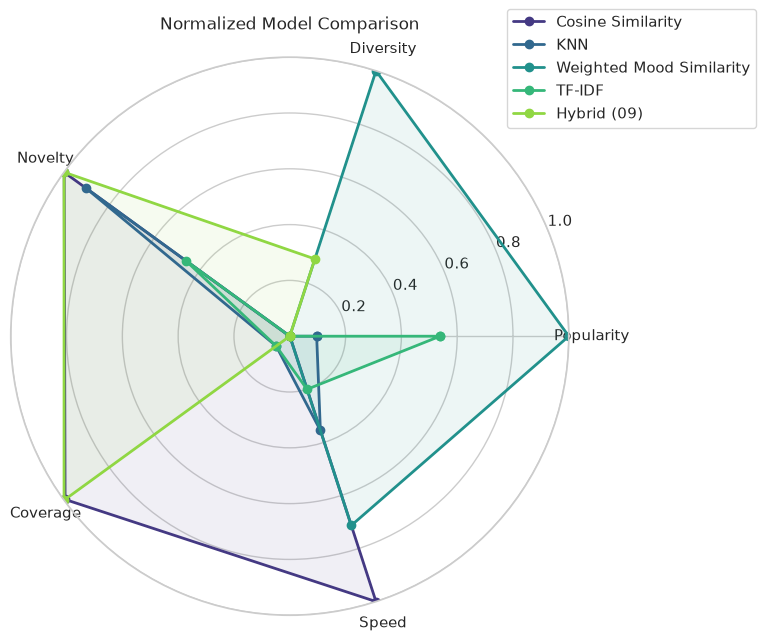

In [3]:
labels = ["Popularity", "Diversity", "Novelty", "Coverage", "Speed"]
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
palette = sns.color_palette("viridis", len(normalized))

for (_, row), color in zip(normalized.iterrows(), palette):
    values = row[radar_metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=row["model"], color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("Normalized Model Comparison", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "radar_chart.png", bbox_inches="tight")
plt.show()

## Winner per metric

In [4]:
winners = {
    "Genre precision": comparison.loc[comparison["genre_precision_at_k"].idxmax(), "model"],
    "Popularity": comparison.loc[comparison["avg_popularity"].idxmax(), "model"],
    "Diversity": comparison.loc[comparison["diversity_score"].idxmax(), "model"],
    "Novelty": comparison.loc[comparison["novelty_score"].idxmax(), "model"],
    "Catalog coverage": comparison.loc[comparison["catalog_coverage"].idxmax(), "model"],
    "Speed": comparison.loc[comparison["avg_response_time_s"].idxmin(), "model"],
}

pd.Series(winners, name="winner")

Genre precision            Cosine Similarity
Popularity          Weighted Mood Similarity
Diversity           Weighted Mood Similarity
Novelty                          Hybrid (09)
Catalog coverage                 Hybrid (09)
Speed                      Cosine Similarity
Name: winner, dtype: str

## Feature -> model mapping

In [5]:
mapping = pd.DataFrame([
    {"model": "Cosine Similarity", "recommended_feature": "Similar song", "rationale": "narrow genre-matched similarity search"},
    {"model": "KNN", "recommended_feature": "Playlist", "rationale": "only model that takes a track list and spans every genre in it"},
    {"model": "Weighted Mood Similarity", "recommended_feature": "Mood", "rationale": "wins both avg_popularity and diversity_score"},
    {"model": "TF-IDF", "recommended_feature": "Genre browse", "rationale": "hard genre gate, cheapest to query"},
    {"model": "Hybrid (09)", "recommended_feature": "General fallback", "rationale": "blends numeric, categorical, and text signal into one score"},
])
mapping

,model,recommended_feature,rationale
0,Cosine Similarity,Similar song,narrow genre-matched similarity search
1,KNN,Playlist,only model that takes a track list and spans e...
2,Weighted Mood Similarity,Mood,wins both avg_popularity and diversity_score
3,TF-IDF,Genre browse,"hard genre gate, cheapest to query"
4,Hybrid (09),General fallback,"blends numeric, categorical, and text signal i..."


## Limitations

- no user-interaction history, content-based only
- 05/06/08 hard-gate by genre, so diversity_score is a flat 0.1 for those three
- 07 only has 4 mood buckets
- coverage above is bounded by the benchmark sample size, not a hard ceiling
- no personalization, no feedback loop, no cold-start handling

In [6]:
gated_models = ["Cosine Similarity", "KNN", "TF-IDF"]
comparison.loc[comparison["model"].isin(gated_models), ["model", "diversity_score"]]

,model,diversity_score
0,Cosine Similarity,0.1
1,KNN,0.1
3,TF-IDF,0.1


## Final summary

In [7]:
final_summary = comparison.merge(mapping, on="model", how="left")
final_summary.to_csv(TABLES_DIR / "final_summary.csv", index=False)
final_summary

,model,use_case,genre_precision_at_k,artist_precision_at_k,avg_popularity,diversity_score,novelty_score,catalog_coverage,avg_response_time_s,recommended_feature,rationale
0,Cosine Similarity,similar_song,1.000,0.134,31.4320,0.1000,0.6857,0.0219,0.0061,Similar song,narrow genre-matched similarity search
1,KNN,playlist,1.000,NaN,36.6533,0.1000,0.6335,0.0017,0.0151,Playlist,only model that takes a track list and spans e...
2,Weighted Mood Similarity,mood,NaN,NaN,85.9000,0.7750,0.1410,0.0004,0.0083,Mood,wins both avg_popularity and diversity_score
3,TF-IDF,genre,1.000,NaN,60.7600,0.1000,0.3924,0.0017,0.0234,Genre browse,"hard genre gate, cheapest to query"
4,Hybrid (09),similar_song,0.714,0.204,31.4030,0.2965,0.6860,0.0220,0.0806,General fallback,"blends numeric, categorical, and text signal i..."
